In [1]:
import pandas as pd
messages = pd.read_csv('/kaggle/input/datasets/msp689/smsspam/SMSSpamCollection.txt',sep = "\t",names = ["labels","message"])

## In previous two codes of spamham there was a major issue, we were performing Tfidf or BOW (Word embedding) before train test split which can lead to data leakage hence we need to do train-test-split before performing embbeding techniques

In [2]:
messages

,labels,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## Data Cleaning and Preprocessing


In [3]:
import re        #regularization
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [4]:
corpus = []
for i in range(0,len(messages)):
    review = re.sub('[^a-zA-z]', ' ',messages['message'][i]) ## Keep only alphabets and any other character will be get replaced by space
    review = review.lower()
    review = review.split()
    review = [lemmatizer.lemmatize(word,pos='v') for word in review if word not in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

In [5]:
## Output
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(messages['labels'])

In [6]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

## Train-Test-Split

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(corpus,y,test_size=0.2,random_state=42)

## Tfidf or BOW

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf = TfidfVectorizer(max_features = 2500,ngram_range=(1,2))

In [9]:
X_train = Tfidf.fit_transform(X_train).toarray()
X_test = Tfidf.transform(X_test).toarray()

In [10]:
X_train.shape

(4457, 2500)

In [11]:
X_test.shape

(1115, 2500)

## Model Training

In [12]:
from sklearn.naive_bayes import MultinomialNB ## Works well with sparse data
spam_detector = MultinomialNB()

In [13]:
spam_detector.fit(X_train,y_train)

MultinomialNB()

In [14]:
y_pred = spam_detector.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay,confusion_matrix,classification_report
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.979372197309417


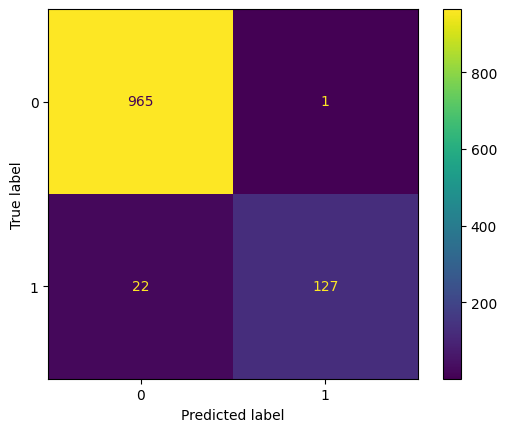

In [16]:
import matplotlib.pyplot as plt
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred)).plot()
plt.show()

In [17]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

